In [9]:

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
event_labels = {'boogaloo': 'political',
 'boulderfire': 'disaster',
 'buffaloshooting': 'violence',
 'coupdc': 'political',
 'elpaso': 'violence',
 'floodtx': 'disaster',
 'hawaiifires': 'disaster',
 'helene': 'disaster',
 'lewiston': 'violence',
 'montereypark': 'violence',
 'socalfires': 'disaster',
 'uvalde': 'violence',
 'virginiabeach': 'violence',
 'vehiclela': 'violence'}

In [ ]:
events_org = {
    'violence': ['boulderfire', 'buffaloshooting', 'elpaso',
                 'montereypark', 'uvalde', 'virginiabeach'],
    'disaster': ['floodtx', 'hawaiifires', 'helene', 'socalfires', "tornadokentucky", "firekansas"]
}


In [13]:
violence_dfs = []
disaster_dfs = []

In [ ]:
data_id = "hits=2"
datasets_dir = Path(f"output/{data_id}/")

datasets = [d.name for d in datasets_dir.iterdir() if d.is_dir()]
if "lewiston" in datasets:
    datasets.remove("lewiston")

# days you want to attempt
day_files = {
    -7: "day_-7.csv",
     0: "day_0.csv",
     4: "day_4.csv",
     5: "day_5.csv",
    10: "day_10.csv",
    11: "day_11.csv",
    30: "day_30.csv",
}

def dataset_group(dataset: str, events_org: dict) -> str | None:
    if dataset in events_org.get("violence", []):
        return "violence"
    if dataset in events_org.get("disaster", []):
        return "disaster"
    return None

rows = []

for dataset in datasets:
    group = dataset_group(dataset, events_org)
    if group is None:
        print(f"Skipping (not in events_org): {dataset}")
        continue

    words_counts_dir = datasets_dir / dataset / "words_counts" / "event"

    for day, fname in day_files.items():
        path = words_counts_dir / fname
        if not path.exists():
            # skip missing files (your requested behavior)
            print(f"Skipping missing file: {path}")
            continue

        df = pd.read_csv(path)
        df["dataset"] = dataset
        df["day"] = day
        df["group"] = group
        rows.append(df)

# One combined DF + two views
all_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

violence_df = all_df[all_df["group"] == "violence"].reset_index(drop=True)
disaster_df = all_df[all_df["group"] == "disaster"].reset_index(drop=True)


Skipping (not in events_org): milton
Skipping missing file: output/hits=2/firekansas/words_counts/event/day_10.csv
Skipping missing file: output/hits=2/firekansas/words_counts/event/day_20.csv
Skipping missing file: output/hits=2/socalfires/words_counts/event/day_30.csv
Skipping missing file: output/hits=2/boulderfire/words_counts/event/day_20.csv
Skipping missing file: output/hits=2/boulderfire/words_counts/event/day_30.csv
Skipping (not in events_org): boogaloo


In [311]:
collapse_map_v = {

    # ---------------------------------------------------
    # Political leadership & federal response
    # ---------------------------------------------------
    "president": [
        "president", "u.s. president", "white house",
        "administration", "executive branch",
        "trump", "donald trump",
        "biden", "joe biden"
    ],

    # ---------------------------------------------------
    # Geographic & venue anchors (filtering only)
    # ---------------------------------------------------
    "state": [
        "state", "governor", "state government",
        "city",
        "el paso", "el", "paso",
        "new york", "york", "york city", "new",
        "texas", "tx",
        "uvalde", "uvalde texas",
        "buffalo", "buffaloshooting", "buffalo new york",
        "virginia", "virginia beach",
        "monterey", "monterey park",
        "california",

        "elementary", "elementary school", "uvalde elementary",
        "middle school", "high school",
        "school", "campus",
        "college", "university",

        "church", "synagogue", "mosque", "temple",
        "supermarket", "grocery", "grocery store", "market",
        "nightclub", "club",
        "bar",
        "mall", "shopping center",
        "concert", "festival"
    ],

    # ---------------------------------------------------
    # Policy, law, and regulation discourse
    # ---------------------------------------------------
    "legislation": [
        "legislation", "law", "bill", "act",
        "gun law", "gun control", "firearms regulation",
        "weapons ban", "assault weapons ban",
        "background checks",
        "congress", "senate", "house of representatives",
        "policy", "public policy",
        "executive order"
    ],

    # ---------------------------------------------------
    # Law enforcement & investigation
    # ---------------------------------------------------
    "police": [
        "police", "cops", "law enforcement",
        "officers", "deputies",
        "sheriff", "state troopers",
        "fbi", "atf", "homeland security",
        "authorities", "investigators",
        "swat", "task force",

        "arrest", "arrested", "custody",
        "charge", "charges", "charged"
    ],

    # ---------------------------------------------------
    # Violent event & attack language
    # ---------------------------------------------------
    "shooting": [
        "shooting", "shoot", "shot",
        "mass", "mass shooting", "mass-shooting",
        "active shooter",
        "gunfire",
        "drive by shooting",
        "school shooting", "church shooting",
        "nightclub shooting",
        "attack", "violent attack"
    ],

    # ---------------------------------------------------
    # Weapons & equipment
    # ---------------------------------------------------
    "firearm": [
        "firearm", "gun",
        "handgun", "pistol",
        "rifle", "ar-15", "ar15", "assault rifle",
        "shotgun",
        "weapon",
        "ammunition", "bullets", "magazine"
    ],

    # ---------------------------------------------------
    # Casualties & human impact
    # ---------------------------------------------------
    "victims": [
        "victims",
        "dead", "death", "deaths",
        "fatality", "fatalities",
        "killed", "kill", 
        "injuries", "wounded",
        "casualties",
        "survivors", "people", "old", "year old", "student", "teacher"
    ],

    # ---------------------------------------------------
    # Perpetrator identity
    # ---------------------------------------------------
    "suspect": [
        "suspect",
        "shooter", "gunman",
        "assailant", "attacker",
        "perpetrator",
        "person of interest"
    ],

    # ---------------------------------------------------
    # Ideological violence & radicalization
    # ---------------------------------------------------
    "extremism": [
        "extremism", "violent extremism",
        "radicalization", "radicalized",
        "militant ideology",
        "fanaticism",
        "political extremism",
        "religious extremism",
        "fringe ideology"
    ],

    # ---------------------------------------------------
    # Terror & mass-casualty violence
    # ---------------------------------------------------
    "violence": [
        "terror", "terrorism", "terrorist",
        "domestic terrorism",
        "political violence",
        "ideological violence",
        "mass casualty attack",
        "insurgent violence" , "gun violence", "violence"
    ],

    # ---------------------------------------------------
    # Bias-motivated violence
    # ---------------------------------------------------
    "hate crime": [
        "hate", "hate crime",
        "bias crime",
        "racially motivated",
        "religiously motivated",
        "identity based attack",
        "targeted attack",
        "ideological hatred", "black", "latinx", "hate_crime"
    ],

    # ---------------------------------------------------
    # Racist ideology & identity-based violence
    # ---------------------------------------------------
    "racism": [
        "racism", "racial violence",
        "white supremacy", "supremacist",
        "neo nazi", "nazism",
        "antisemitism", "antisemitic",
        "islamophobia",
        "xenophobia",
        "racial hatred", "white", 
    ]
}


# Build reverse lookup once
variant_to_canonical = {
    v.lower(): canonical
    for canonical, variants in collapse_map_v.items()
    for v in variants
}

def normalize_word(w):
    # Handle NaN / non-strings safely
    if pd.isna(w):
        return w  # keep NaN (or return "" if you prefer)
    w = str(w).lower().strip()
    return variant_to_canonical.get(w, w)

# Apply
violence_df["word_norm"] = violence_df["word"].apply(normalize_word)

In [ ]:
collapse_map_d = {
    # ---------------------------------------------------
    # Aid / response
    # ---------------------------------------------------
    "rescue": [
        "rescue", "rescues",
        "search and rescue", "sar",
        "rescue operation", "rescue operations",
        "emergency rescue", "water rescue",
        "air rescue", "swift water rescue",
        "evacuation", "evacuations",
        "evacuated", "evacuating",
        "emergency response", "first responders", "search"
    ],

    "help": [
        "help", "aid", "assistance",
        "relief", "support",
        "emergency help", "emergency assistance",
        "disaster relief", "humanitarian aid",
        "supplies", "donations","recovery",
        "volunteers", "volunteer efforts", "response"
    ],

    "victims": [
        "victims", "survivors",
        "residents", "families",
        "people affected", "those affected",
        "displaced residents", "evacuees", "people"
    ],

    "federal aid": [
        "federal aid", "federal assistance",
        "federal help", "federal response",
        "fema", "disaster declaration",
        "emergency declaration",
        "presidential declaration",
        "national guard",
        "relief funding", "emergency funding", "federal", "official"
    ],

    # ---------------------------------------------------
    # Event specific: natural disasters
    # ---------------------------------------------------
    "natural disaster": ["helene", "milton",
        "natural disaster", "disaster", "catastrophe",

        # storms & cyclones
        "hurricane", "tornado", "storm",
        "tropical storm", "tropical cyclone",
        "cyclone", "typhoon",
        "hurricane helene", "storm helene",
        "tropical storm helene",

        # flooding
        "flood", "flooding", "flash flood", "flash flooding",
        "floodwaters", "high water",
        "storm surge", "surge",
        "rain", "rainfall", "heavy rain",
        "downpour",

        # wind
        "wind", "winds", "high winds",
        "gust", "gusts","flash",

        # fires
        "wildfire", "wildfires",
        "fire", "fires",
        "brush fire", "forest fire",
        "structure fire",

        # notable fire events
        "maui fires", "maui wildfire", "maui wildfires",
        "hawaii fires", "hawaii wildfire", "hawaiifires",
        "socal fires", "so cal fires",
        "southern california fires", "california fires",
        "socalfires"
    ],
    # ---------------------------------------------------
    # Casualties
    # ---------------------------------------------------
    "fatalities": [
        "dead", "death", "deaths",
        "fatality", "fatalities",
        "killed", "loss of life",
        "lives lost",
        "body", "bodies",
        "confirmed dead", "death toll",
        "rising death toll", "kill"
    ],

    # ---------------------------------------------------
    # Infrastructure & property impact
    # ---------------------------------------------------
    "damage": [
        "damage", "damages",
        "destruction", "destroyed",
        "ruined", "leveled",
        "collapsed", "collapse",
        "wrecked", "burned",
        "flooded homes", "flooded streets","home", "homes"

        "power outage", "power outages",
        "outage", "outages",
        "blackout", "blackouts",
        "downed power lines",

        "road closures", "closed roads",
        "bridge collapse", "washed out roads",
        "infrastructure damage",
        "property damage", "impact"
    ],

    # ---------------------------------------------------
    # Severity & scale
    # ---------------------------------------------------
    "devastating": [
        "devastating", "catastrophic",
        "historic", "record breaking",
        "unprecedented", "massive",
        "severe", "extreme",
        "deadly", "destructive",
        "crippling", "widespread",
        "chaotic", "disastrous"
    ],
##policy
    "president": [
        "president", "u.s. president", "white house",
        "administration", "executive branch",
        "trump", "donald trump",
        "biden", "joe biden",
    ],
    "state of emergency": ["state of emergency", "emergency declaration", "declared emergency","emergency"],
    "evacuation" : ["evacuation", "evacuate", "evacuations", "evacuated"],
    "state":   
        ["tx", "texas","ca", "calif", "california","hi", "hawaii", "hawaiian","fl", "florida","nc", "north carolina",
         "sc", "south carolina","ga", "georgia","tn", "tennessee","va", "virginia","al", "alabama",

        # --- Places / Cities / Regions ---
        # Hawaii / Maui
        "maui",
        "lahaina",
        "maui county",
        "honolulu",
        "kentucky",
        # Southern California / LA region
        "los angeles", "la", "l.a.", "los angeles county", "los", "angeles",
        "san diego", "san diego county",
        "ventura", "ventura county",
        "orange county", "oc",
        
        # Texas flood common cities/regions
        "houston",
        "austin",
        "san antonio",
        "dallas",
        "hill country", "texas hill country","central texas","island", "county"],
    }

variant_to_canonical_d = {
    v.lower(): canonical
    for canonical, variants in collapse_map_d.items()
    for v in variants
}

def normalize_word_d(w):
    if pd.isna(w):
        return w
    w = str(w).lower().strip()
    return variant_to_canonical_d.get(w, w)

disaster_df["word_norm"] = disaster_df["word"].apply(normalize_word_d)

In [339]:
top_v_words = ["police","shooting",
               "firearm", "victims", "suspect", "extremism",
               "violence", "hate crime","racism","president","legislation","state"]

In [242]:
top_d_words = ["rescue","help","victims", "federal aid",
               "natural disaster", "fatalities","damage","devastating",
               "state","president","state of emergency","evacuation"
]

In [340]:
target_words_v = [w.lower().strip() for w in top_v_words]

day_word_avg_v = (
    violence_df[violence_df["word_norm"].isin(target_words_v)]
    .groupby(["day", "word_norm"], as_index=False)
    .agg(tfidf=("tfidf", "mean"))
)

radar_df_v = (
    day_word_avg_v
    .pivot(index="day", columns="word_norm", values="tfidf")
    .fillna(0.0)
)

# Ensure column order matches top_v_words
radar_df_v = radar_df_v.reindex(columns=target_words_v, fill_value=0.0)


In [243]:
target_words_d = [w.lower().strip() for w in top_d_words]

day_word_avg_d = (
    disaster_df[disaster_df["word_norm"].isin(target_words_d)]
    .groupby(["day", "word_norm"], as_index=False)
    .agg(tfidf=("tfidf", "mean"))
)

radar_df_d = (
    day_word_avg_d
    .pivot(index="day", columns="word_norm", values="tfidf")
    .fillna(0.0)
)

# Ensure column order matches top_v_words
radar_df_d = radar_df_d.reindex(columns=target_words_d, fill_value=0.0)


In [226]:
def plot_radar_for_day(day, values, labels, normalize=True, label_pad=18):
    vals = values.astype(float).values

    # Normalize per day so radar shows shape
    if normalize and vals.max() > 0:
        vals = vals / vals.max()

    # Close loop
    vals = np.append(vals, vals[0])
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
    angles = np.append(angles, angles[0])

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    ax.plot(angles, vals, linewidth=2)
    ax.fill(angles, vals, alpha=0.25)

    # ---- Move labels outward ----
    ax.set_thetagrids(angles[:-1] * 180 / np.pi, labels)
    ax.tick_params(axis='x', pad=label_pad)

    # ---- Rotate labels to follow circle ----
    for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
        angle_deg = np.degrees(angle)
        label.set_rotation(angle_deg)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("center")

    ax.set_ylim(0, 1.05 if normalize else vals.max() * 1.05)
    ax.set_title(f"Disaster — Day {day} — Avg TF-IDF (normalized)", y=1.12)

    plt.show()


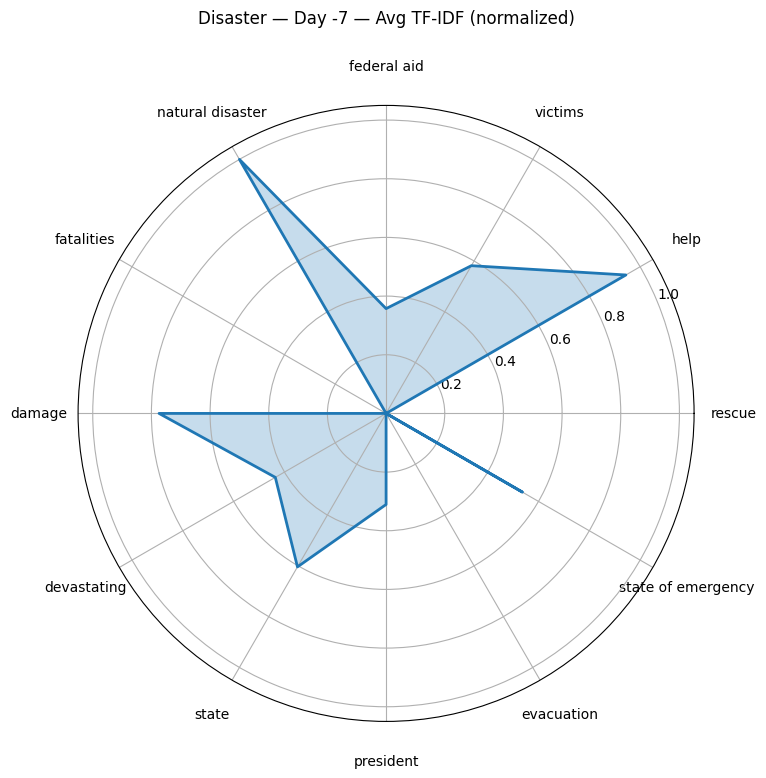

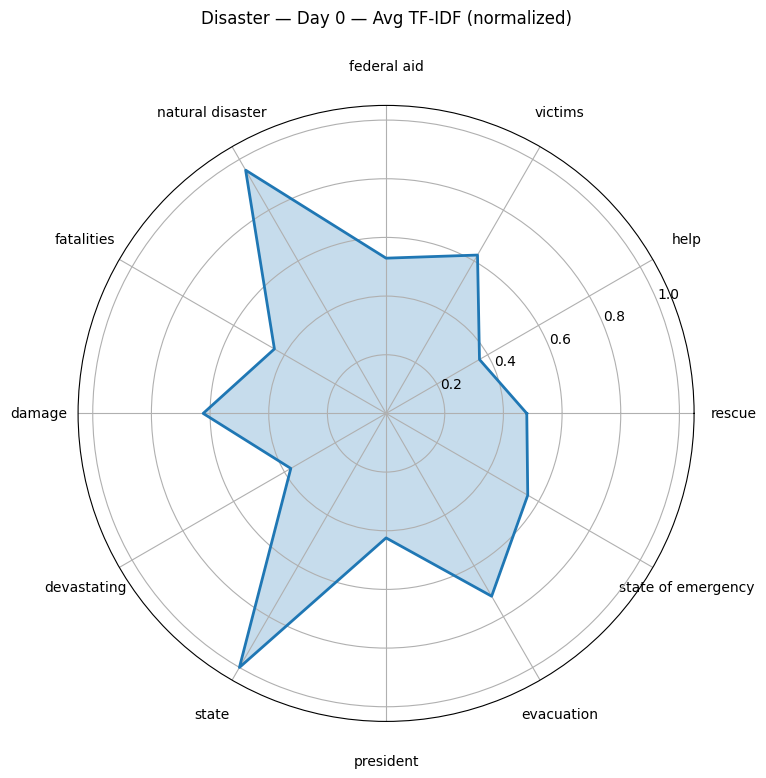

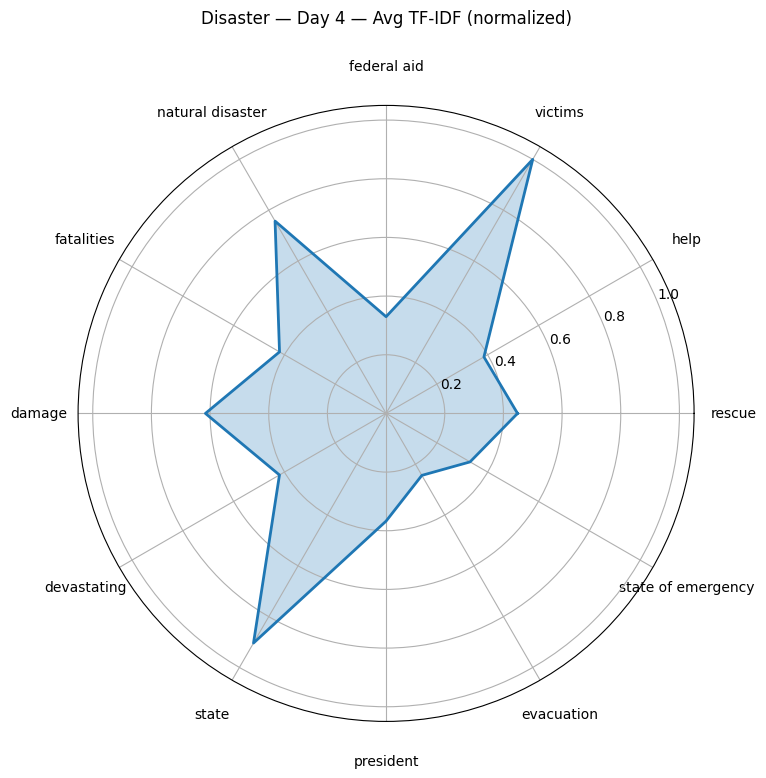

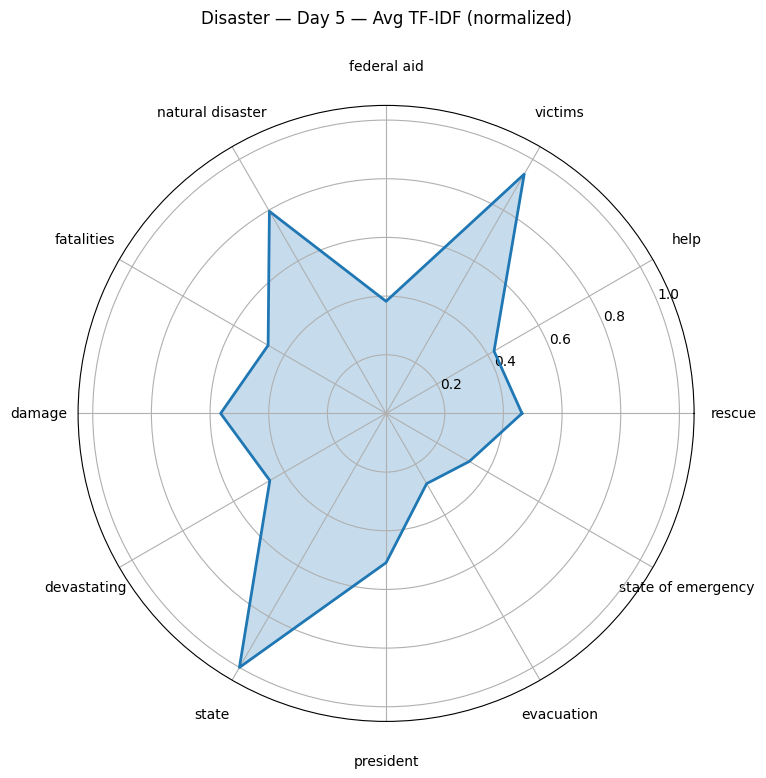

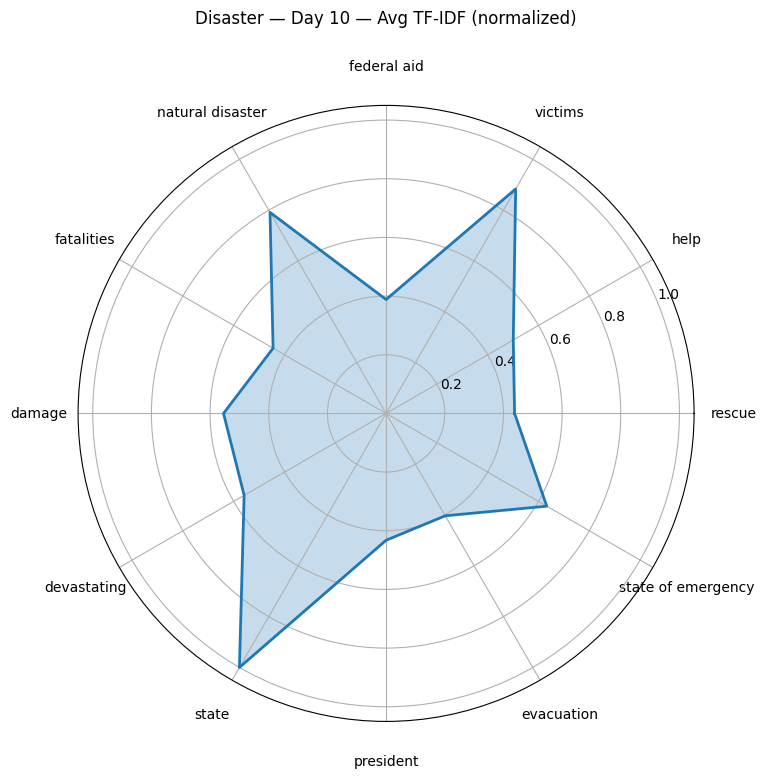

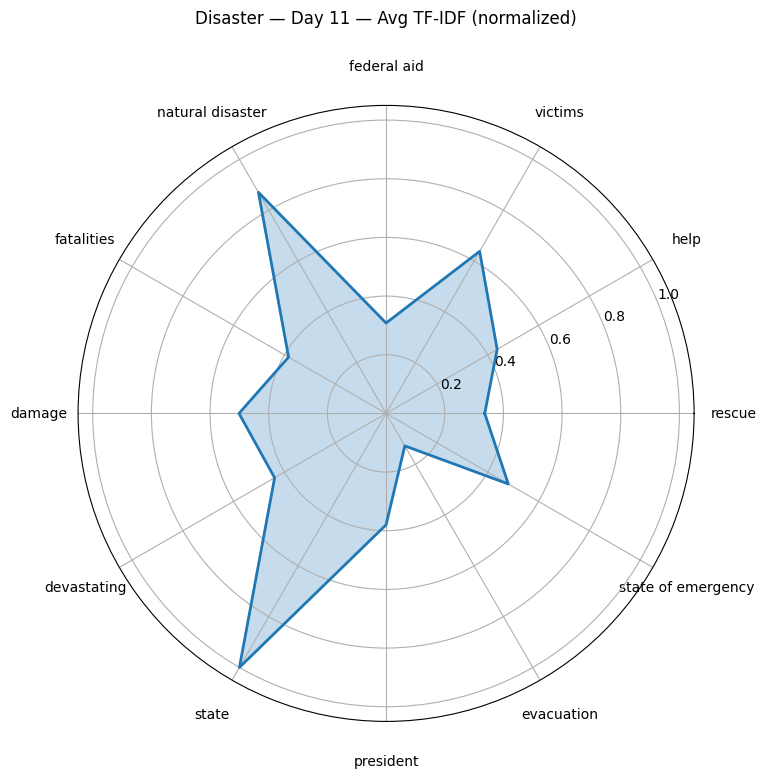

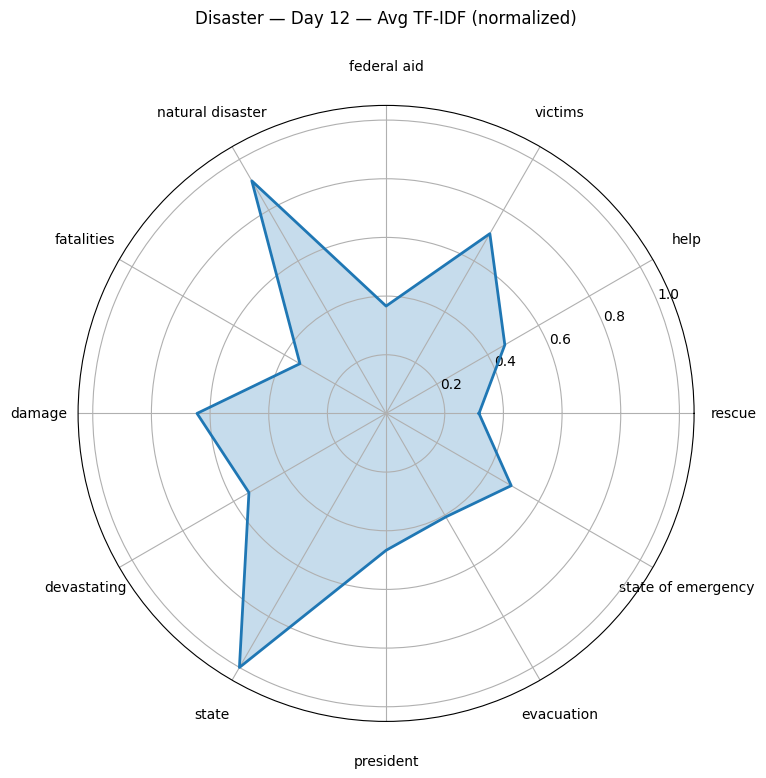

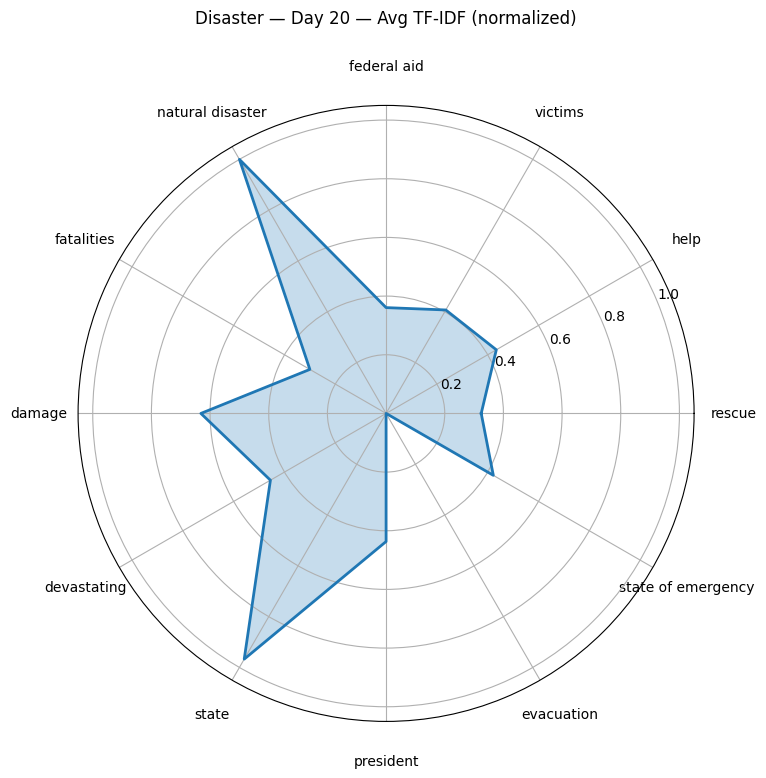

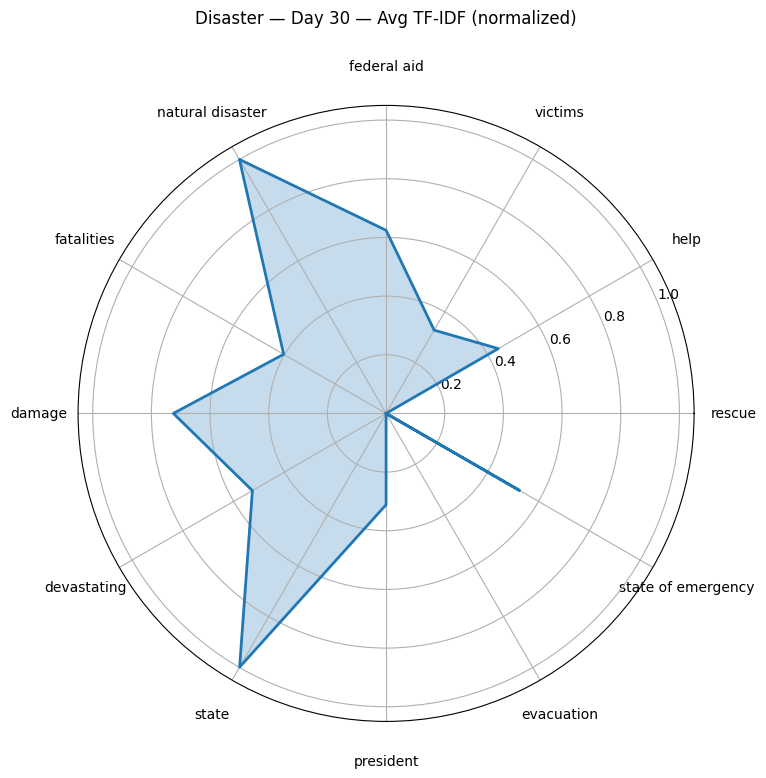

In [227]:
for day in sorted(radar_df_d.index):
    plot_radar_for_day(day, radar_df_d.loc[day], radar_df_d.columns, normalize=True)


In [324]:
def plot_radar_overlay_days(
    radar_df,
    days=None,
    word_order=None,
    normalize=True,
    title=None,
    label_pad=25,
    colors=None,                   # list aligned with days OR dict {day: color}
    fade_days=None,                # subset of days to fade (outline only)
    line_alpha_fade=0.35,          # opacity for faded outlines
    line_alpha_keep=0.90,          # opacity for non-faded lines
    fill_alpha_keep=0.18,          # opacity for filled regions
    linewidth=4,
    radius_scale=0.90,             # <--- shrink circle (1.0 = default)
    figsize=(8, 8),
    outpath="radar_overlay.pdf",
    font_size = 22
):
    plt.rcParams['font.size'] = font_size

    # Pick days
    if days is None:
        days = sorted(radar_df.index.tolist())
    else:
        days = list(days)

    fade_days = set(fade_days) if fade_days is not None else set()

    # Axis order
    if word_order is None:
        labels = list(radar_df.columns)
    else:
        labels = [w for w in word_order if w in radar_df.columns]

    if len(labels) < 3:
        raise ValueError("Need at least 3 words/axes for a radar plot.")

    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
    angles = np.append(angles, angles[0])

    # Color resolver
    def get_color(day, i):
        if isinstance(colors, dict):
            return colors.get(day, None)
        if isinstance(colors, (list, tuple)):
            return colors[i] if i < len(colors) else None
        return None

    fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(polar=True))

    for i, day in enumerate(days):
        if day not in radar_df.index:
            continue

        vals = radar_df.loc[day, labels].astype(float).values
        if normalize and vals.max() > 0:
            vals = vals / vals.max()

        vals = np.append(vals, vals[0])

        color = get_color(day, i)
        is_faded = day in fade_days

        line_alpha = line_alpha_fade if is_faded else line_alpha_keep

        # Outline
        ax.plot(
            angles, vals,
            linewidth=linewidth,
            label=f"Day {day}",
            color=color,
            alpha=line_alpha,
            linestyle="--" if is_faded else "-"
        )

        # Fill only for non-faded
        if not is_faded:
            ax.fill(angles, vals, color=color, alpha=fill_alpha_keep)

    # Labels
    ax.set_thetagrids(angles[:-1] * 180 / np.pi, labels)
    ax.tick_params(axis="x", pad=label_pad)

    for lbl, ang in zip(ax.get_xticklabels(), angles[:-1]):
        lbl.set_rotation(np.degrees(ang))

    # ---- Radius scaling (circle size control) ----
    max_r = 1.05 if normalize else max(radar_df.loc[days, labels].max())
    ax.set_ylim(0, max_r * radius_scale)

    # Optional title
    if title:
        ax.set_title(title, y=1.12)

    # Save PDF
    outpath = Path(outpath)
    outpath.parent.mkdir(parents=True, exist_ok=True)

    plt.tight_layout()
    plt.savefig(outpath, format="pdf", bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved radar overlay to: {outpath}")


In [326]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_radar_legend(
    days,
    colors=None,
    fade_days=None,
    linewidth=4,
    figsize=(6, 4),
    outpath="radar_legend.pdf",
    title="Legend"
):

    fade_days = set(fade_days) if fade_days is not None else set()

    handles = []

    for i, day in enumerate(days):
        if isinstance(colors, dict):
            color = colors.get(day, None)
        elif isinstance(colors, (list, tuple)):
            color = colors[i] if i < len(colors) else None
        else:
            color = None

        linestyle = "--" if day in fade_days else "-"
        alpha = 0.35 if day in fade_days else 0.9

        handles.append(
            Line2D(
                [0], [0],
                color=color,
                linewidth=linewidth,
                linestyle=linestyle,
                alpha=alpha,
                label=f"Day {day}"
            )
        )

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    ax.legend(
        handles=handles,
        loc="center",
        frameon=False,
        title=title,
        fontsize=18,
        title_fontsize=20
    )

    outpath = Path(outpath)
    outpath.parent.mkdir(parents=True, exist_ok=True)

    plt.tight_layout()
    plt.savefig(outpath, format="pdf", bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved legend to: {outpath}")


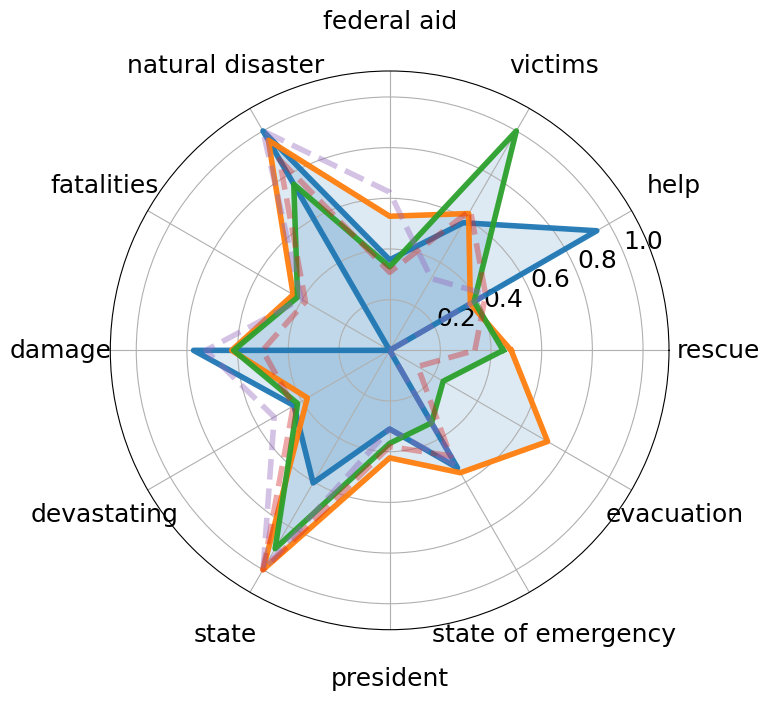

Saved radar overlay to: figures/disaster_1-2_overlay.pdf


In [351]:
plot_radar_overlay_days(
    radar_df_d,
    days=[-7,0,4,11,30],
    normalize=True,
    title=None,
    label_pad=25,
    colors=None,                   
    fade_days=[11,30],               
    line_alpha_fade=0.40,         
    line_alpha_keep=0.95,          
    fill_alpha_keep=0.15,          
    linewidth=4,
    radius_scale=1.05,             
    figsize=(8, 8),
    outpath="figures/disaster_1-2_overlay.pdf",
    font_size = 18)

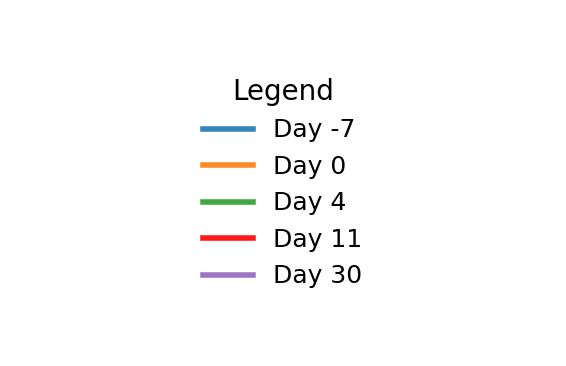

Saved legend to: figures/radar_legend_disaster.pdf


In [348]:
plot_radar_legend(
    days=[-7,0,4,11,30],
    colors = ["#1f77b4","#ff7f0e","#2ca02c","#FF0000","#9467bd"],
    outpath="figures/radar_legend_disaster.pdf"
)